# ANN-Based Energy Consumption Predictor

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load Dataset
df = pd.read_csv("dataset/energy.csv")
df.head()


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
df = df.sample(5000, random_state=42)


In [4]:
print(df.columns)

Index(['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3',
       'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8',
       'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'rv1', 'rv2'],
      dtype='object')


In [5]:

# DATA PREPROCESSING


# Check dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Remove missing values if any
df = df.dropna()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract useful time features
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month

# Drop original date column
df = df.drop('date', axis=1)

# ==============================
# FEATURES AND TARGET
# ==============================

# Target variable
y = df['Appliances']

# Feature variables
X = df.drop('Appliances', axis=1)

# ==============================
# TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==============================
# FEATURE SCALING
# ==============================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing completed successfully!")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 8980 to 14591
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         5000 non-null   object 
 1   Appliances   5000 non-null   int64  
 2   lights       5000 non-null   int64  
 3   T1           5000 non-null   float64
 4   RH_1         5000 non-null   float64
 5   T2           5000 non-null   float64
 6   RH_2         5000 non-null   float64
 7   T3           5000 non-null   float64
 8   RH_3         5000 non-null   float64
 9   T4           5000 non-null   float64
 10  RH_4         5000 non-null   float64
 11  T5           5000 non-null   float64
 12  RH_5         5000 non-null   float64
 13  T6           5000 non-null   float64
 14  RH_6         5000 non-null   float64
 15  T7           5000 non-null   float64
 16  RH_7         5000 non-null   float64
 17  T8           5000 non-null   float64
 18  RH_8         5000 non-null   float64
 19  T9     

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Model training completed!
Mean Absolute Error: 51.964084205876844
Root Mean Squared Error: 92.74270343499848


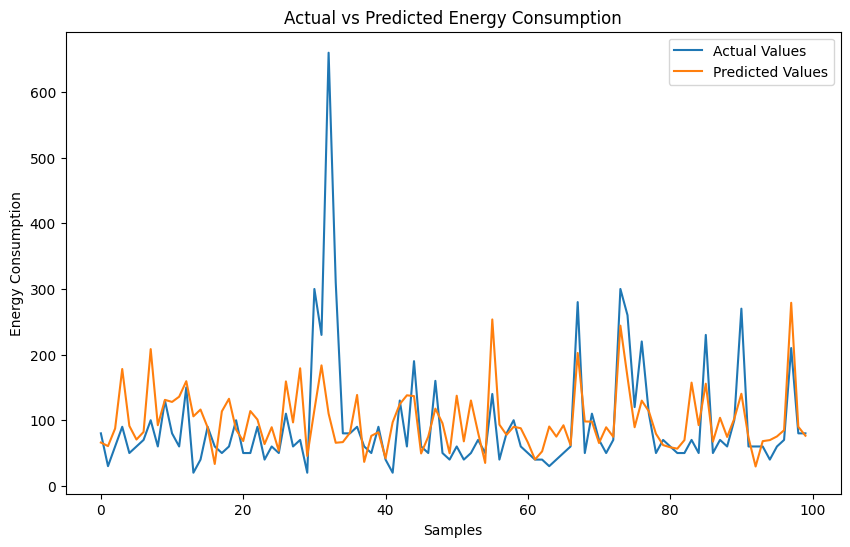

In [6]:
# ANN MODEL TRAINING


from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Create ANN model
model = MLPRegressor(
    hidden_layer_sizes=(32,16),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

print("Model training completed!")

# MODEL EVALUATION


# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

# VISUALIZATION


plt.figure(figsize=(10,6))

plt.plot(y_test.values[:100], label='Actual Values')
plt.plot(y_pred[:100], label='Predicted Values')

plt.xlabel("Samples")
plt.ylabel("Energy Consumption")
plt.title("Actual vs Predicted Energy Consumption")

plt.legend()
plt.show()